In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab.patches import cv2_imshow

# <font color=blue>Movimiento y flujo óptico</font>


En este notebook encontrarás la teoría y los fundamentos necesarios para realizar las actividades relacionadas con **detección de movimiento** y **flujo óptico**.

## <font color="#F20C60">¿Qué es el movimiento en visión por computadora?</font>

La detección de movimiento se utiliza para identificar los objetos que cambian de posición entre dos o más cuadros consecutivos en una secuencia de video o imágenes.

El **flujo óptico** es una técnica que permite estimar el movimiento de los píxeles entre dos cuadros consecutivos, detectando cómo se desplazan los objetos.

**Aplicaciones:**
- Seguimiento de objetos.
- Análisis de video.
- Robótica y navegación autónoma.

## <font color="#F20C60"> Detección de Movimiento mediante Diferencias de Cuadros</font>

### <font color="#770EB2">¿Cómo funciona?</font>

La técnica de diferencias de cuadros consiste en comparar dos imágenes consecutivas y calcular la diferencia entre ellas para identificar las regiones que han cambiado.

### <font color=green> Ejemplo </font>


Crearemos dos imágenes idénticas con todos ceros, de tamaño 256 × 256 píxeles, utilizando la función `np.zeros()`.

In [40]:
w,h = 256,256
g1 = np.zeros((w,h),dtype = np.uint8)
g2 = np.zeros((w,h),dtype = np.uint8)

El siguiente paso es crear un bucle 'for' e iterarlo sobre todos los valores de píxeles, para crear la transición de escala de grises a lo largo de la diagonal de nuestras imágenes.

In [41]:
for i in range(256):
    for j in range(256):
        g1[i,j] = i//2+j//2
        g2[i,j] = i//2+j//2

Crearemos una pequeña máscara del tamaño 30 × 30. En la esquina superior izquierda de la primera imagen, usando la función `np.ones()`. A continuación, estableceremos todos los valores de píxel en 200 y definiremos la ubicación de la máscara en la primera imagen, junto con la ubicación de la máscara en la segunda imagen. Observe que la ubicación de la máscara en la segunda imagen se desplaza 30 a lo largo del eje de las x (dx = 30), y por 30 a lo largo del eje de las y (dy= 30).

Y, por último, restaremos la primera y la segunda imagen para poder ver la diferencia en el desplazamiento de la máscara.

In [42]:
dx = 20
dy = 20
mask = np.ones((30,30),dtype = np.uint8)*200
g1[20:50,20:50] = mask
g2[20+dy:50+dy, 20+dx:50+dx] = mask
diff = cv2.subtract(g2, g1)

Mostramos la imagen.

**Nota:** Si quieres cargar la imagen con `cv2_imshow()` es necesario cargar la libreria de `from google.colab.patches import cv2_imshow`

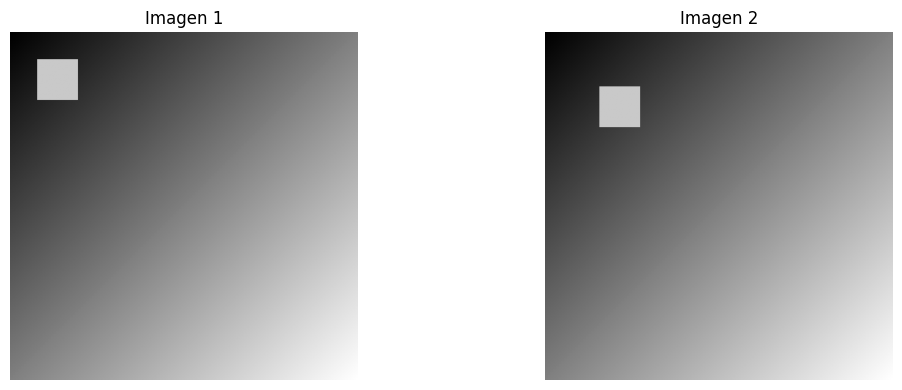

In [43]:
plt.figure(figsize=(12, 4))
titles = ["Imagen 1", "Imagen 2"]
images = [g1, g2]

for i in range(2):
    plt.subplot(1, 2, i + 1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

Observe a continuación cómo todos los píxeles de la imagen tienen valores cero, excepto donde se movió la máscara de una imagen a la otra. Si aplicamos el valor de diferencia absoluta obtenemos las diferencias en ambas imagenes.

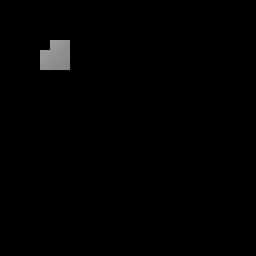

In [44]:
cv2_imshow(diff)

## <font color="#F20C60">Flujo Óptico</font>


### <font color="#770EB2">¿Qué es el flujo óptico?</font>

El flujo óptico representa el movimiento aparente de los objetos, superficies y bordes en una escena visual causada por el movimiento relativo entre un observador y la escena.

### Tipos de flujo óptico:
- **Denso:** Estima el movimiento de todos los píxeles (por ejemplo, Farneback).
- **Escaso:** Estima el movimiento solo de puntos clave (por ejemplo, Lucas-Kanade).

### Aplicaciones:
- Seguimiento de objetos.
- Análisis de patrones de movimiento.
- Navegación autónoma.

### <font color="#770EB2">Flujo Óptico de Lucas-Kanade</font>

### ¿Cómo funciona?
- Busca puntos de interés (esquinas) y los rastrea en el siguiente cuadro.
- Basado en la suposición de que el movimiento es pequeño y constante.


Para mas información puedes dar clic [aqui](https://docs.opencv.org/4.x/db/d7f/tutorial_js_lucas_kanade.html)

### <font color=green> Sintaxis de la función </font>
``` python
 cv.calcOpticalFlowPyrLK (prevImg, nextImg, prevPts, nextPts, status, err, winSize, maxLevel, criteria, flags, minEigThreshold).
```

* `prevImg:` Primera imagen de entrada o pirámide de 8 bits construida por buildOpticalFlowPyramid.
* `nextImg:` segunda imagen de entrada o pirámide del mismo tamaño y tipo que la anterior.
* `prevPts:` vector de puntos 2D para los cuales se necesita encontrar el flujo; las coordenadas de los puntos deben ser números de punto flotante de precisión simple.
* `nextPts:` vector de salida de puntos 2D (con coordenadas de punto flotante de precisión simple) que contiene las nuevas posiciones calculadas de las entidades de entrada en la segunda imagen; cuando se pasa el indicador cv.OPTFLOW_USE_INITIAL_FLOW, el vector debe tener el mismo tamaño que en la entrada.
* `status: vector de estado de salida (de caracteres sin signo); cada elemento del vector se establece en 1 si se ha encontrado el flujo para las características correspondientes, de lo contrario, se establece en 0.
* `err:` vector de salida de errores; cada elemento del vector se establece en un error para la característica correspondiente, el tipo de medida de error se puede establecer en el parámetro de banderas; si no se encontró el flujo, entonces el error no está definido (use el parámetro de estado para encontrar tales casos).
* `winSize:` tamaño de la ventana de búsqueda en cada nivel de la pirámide.
* `maxLevel:` Número de nivel de pirámide máximo basado en 0; si se establece en 0, no se utilizan pirámides (nivel único), si se establece en 1, se utilizan dos niveles, y así sucesivamente; si se pasan pirámides a la entrada, el algoritmo utilizará tantos niveles como pirámides tengan, pero no más que maxLevel.
* `criteria:` 	parámetro, que especifica los criterios de finalización del algoritmo de búsqueda iterativo (después del número máximo de iteraciones especificado, criterio.maxCount, o cuando la ventana de búsqueda se mueve menos que criterio.epsilon).
* `flags:` Esto puede verse como una combinación de lo siguiente:
   * `cv.OPTFLOW_USE_INITIAL_FLOW` utiliza estimaciones iniciales, almacenadas en nextPts; si el indicador no está configurado, entonces prevPts se copia en nextPts y se considera la estimación inicial.
   * `cv.OPTFLOW_LK_GET_MIN_EIGENVALS` utiliza valores propios mínimos como una medida de error (ver descripción de minEigThreshold); si el indicador no está configurado, entonces la distancia L1 entre parches alrededor del original y un punto movido, dividida por el número de píxeles en una ventana, se utiliza como una medida de error.

### <font color=orange> Ejemplo </font>

Ahora, podemos utilizar la función `cv2.cv.calcOpticalFlowPyrLK()` que calcula un flujo óptico escaso para cada píxel utilizando el algoritmo de Lucas-Kanade.

In [58]:
g1_gray = g1
g2_gray = g2

points_to_track = cv2.goodFeaturesToTrack(g1, 100, 0.3, 7)

flowLK, st, err = cv2.calcOpticalFlowPyrLK(g1,g2,points_to_track,None,winSize=(21, 21),maxLevel=3,criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 30, 0.01))

good_new = flowLK[st == 1]
good_old = points_to_track[st == 1]

Dibujar los puntos y líneas del movimiento, como tambien dibujamos las esquinas con circulos.

In [59]:
g2_color = cv2.cvtColor(g2, cv2.COLOR_GRAY2BGR)

for (new, old) in zip(good_new, good_old):
    a, b = new.ravel()
    c, d = old.ravel()
    cv2.line(g2_color, (int(a), int(b)), (int(c), int(d)), (0, 255, 0), 2)
    cv2.circle(g2_color, (int(a), int(b)), 5, (0, 0, 255), -1)

Por ultimo mostramos el resultado

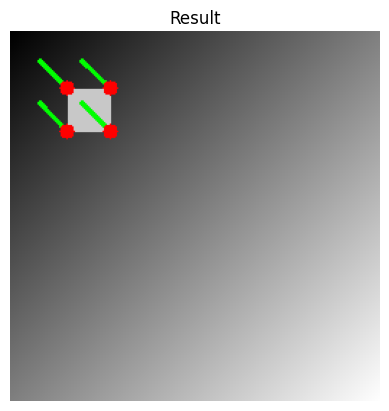

In [61]:
g2_color_rgb = cv2.cvtColor(g2_color, cv2.COLOR_BGR2RGB)

plt.imshow(g2_color_rgb)
plt.title("Result")
plt.axis('off')
plt.show()

### <font color="#770EB2">Flujo Óptico de Farneback</font>

### ¿Cómo funciona?
- Calcula un flujo óptico denso (por cada píxel).
- Útil para observar movimiento general de la escena.


### <font color=green> Sintaxis de la función </font>
``` python
cv2.calcOpticalFlowFarneback(prev , next , flow , pyr_scale , levels, winsize,  iterations, poly_n,  poly_sigma, flags)
```


* `prev:` Imagen de entrada de un solo canal de 8 bits
* `next:` Segunda imagen de entrada del mismo tamaño y tipo que la primera imagen de entrada
* `flow:` Imagen de flujo calculada con el mismo tamaño que la anterior y tipo CV_32FC2.
* `pyr_scale:` Parámetro que especifica la escala de la imagen para construir pirámides para cada imagen; `pyr_scale =0.5` representa una pirámide clásica donde cada capa subsiguiente es el doble de pequeña que la anterior.
* `levels: `Número de capas de la pirámide, incluida la imagen inicial; `levels=1` significa que no se crean capas adicionales y solo se utilizan las imágenes originales
* `winsize:` tamaño de ventana promedio donde los valores más grandes aumentan la robustez del algoritmo al ruido de la imagen y brindan más posibilidades de detección de movimiento rápido, pero producen un campo de movimiento más borroso
* `iterations:` Número de iteraciones realizadas en cada nivel de la pirámide.
* `poly_n:` Tamaño del entorno de píxeles utilizado para determinar la expansión polinómica en cada píxel. Valores mayores significan que la imagen se aproximará con superficies más suaves, lo que produce un algoritmo más robusto y un campo de movimiento más desenfocado. Generalmente, tomamos `poly_n =5 o poly_n =7`
* `poly_sigma:` Desviación estándar de la gaussiana que se utiliza para suavizar las derivadas y se utiliza como base para la expansión polinomial; para `poly_n=5`, podemos establecer `poly_sigma=1.1`; para` poly_n=7`, podemos establecer `poly_sigma=1.5`
* `flags:` Esto puede verse como una combinación de lo siguiente:
  * `OPTFLOW_USE_INITIAL_FLOW` utiliza el flujo de entrada como una aproximación de flujo inicial
  * `OPTFLOW_FARNEBACK_GAUSSIAN` utiliza la función gaussiana ganar tamaño​​​​.
  * Filtro en lugar de un filtro de caja del mismo tamaño para la estimación del flujo óptico; por lo general, esta opción proporcionaz flujo más preciso que con un filtro de caja, a costa de una menor velocidad.

### <font color=orange> Ejemplo </font>

Ahora, podemos utilizar la función `cv2.calcOpticalFlowFarneback()` que calcula un flujo óptico denso para cada píxel utilizando el algoritmo de Gunnar Farneback.

In [15]:
flowGF = cv2.calcOpticalFlowFarneback(g1, g2, None, 0.5, 3, 39,  10,  11,  1.5,cv2.OPTFLOW_FARNEBACK_GAUSSIAN)

A continuación, eliminaremos los valores atípicos generados a partir del proceso de flujo óptico y luego trazaremos este flujo óptico a lo largo del eje `x` y el eje `y`.

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

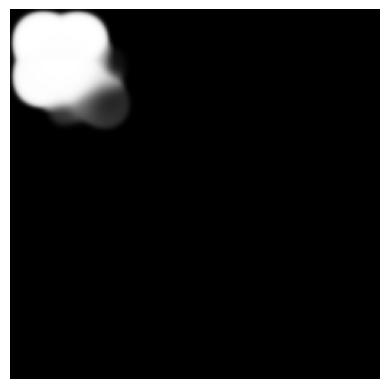

In [16]:
index = (np.abs(flowGF) > 100)
flowGF[index] = 0
index = (np.abs(flowGF)) < 0.001
flowGF[index] = 0
index_interesting = np.abs(flowGF) > 0.1

plt.imshow(flowGF[:,:,1], cmap = 'gray')
plt.axis("off")

Un consejo interesante aquí es que para estimar los valores promedio del flujo, podemos hacer uso de un histograma, creado para todos los puntos con valores absolutos mayores a 0,1.

(array([ 682.,  304.,  236.,  238.,  182.,  168.,  136.,  288.,  396.,
         256.,  184.,  182.,  122.,  132.,  104.,  120.,  104.,   98.,
          78.,  118.,   66.,   46.,   88.,   78.,   60.,   72.,   48.,
          66.,   64.,   72.,   68.,   66.,   74.,   68.,   56.,   86.,
          78.,   56.,   62.,   94.,   90.,  102.,   98.,  120.,  128.,
         156.,  196.,  280.,  514., 5194.]),
 array([ 0.10125795,  0.50116777,  0.90107763,  1.30098748,  1.70089734,
         2.10080719,  2.50071716,  2.9006269 ,  3.30053687,  3.70044684,
         4.10035658,  4.50026608,  4.90017605,  5.30008602,  5.69999552,
         6.09990549,  6.49981546,  6.89972544,  7.29963541,  7.69954491,
         8.09945488,  8.49936485,  8.89927483,  9.2991848 ,  9.69909477,
        10.09900475, 10.49891472, 10.89882469, 11.29873371, 11.69864368,
        12.09855366, 12.49846363, 12.8983736 , 13.29828358, 13.69819355,
        14.09810352, 14.4980135 , 14.89792252, 15.29783249, 15.69774246,
        16.09765

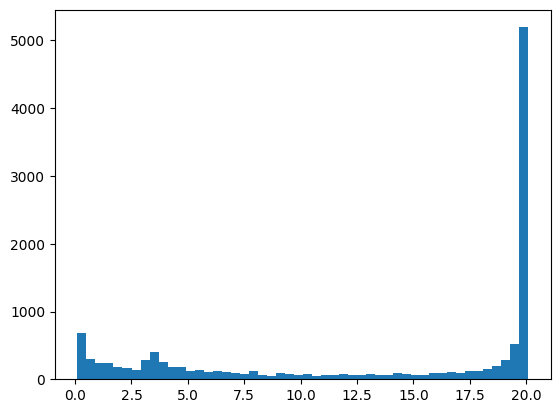

In [17]:
flow_hist = flowGF[index_interesting]
plt.hist(flow_hist.reshape(-1,1), bins = 50)

Como podemos ver, la mayoría de los píxeles con valores mayores que 0 tienen un valor de 20. Ahora, grafiquemos estos resultados usando el espacio de color HSV y observemos el resultado.

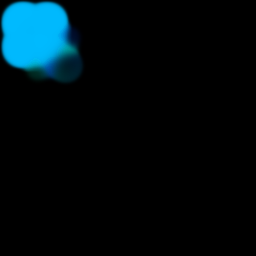

In [22]:
hsv = np.zeros( (256,256,3), dtype = np.uint8)
hsv[...,1] = 255
mag, ang = cv2.cartToPolar(flowGF[...,0], flowGF[...,1])
hsv[...,0] = ang*180/np.pi/2
hsv[...,2] = cv2.normalize(mag,None,0,255,cv2.NORM_MINMAX)
rgb = cv2.cvtColor(hsv,cv2.COLOR_HSV2RGB)
cv2_imshow(rgb)

## <font color="#F20C60">Visualización del Flujo Óptico con Vectores (Farneback)</font>

Una forma común de visualizar el flujo óptico denso es mediante flechas o líneas que muestran la dirección y magnitud del movimiento de cada píxel o región.

### <font color="#770EB2">Explicación:</font>

* Se recorren las posiciones (x, y) de la imagen en pasos (por ejemplo, cada 20 píxeles para no sobrecargar de flechas).
* Se obtiene el vector de flujo (fx, fy) en esa posición.
* Se dibuja una flecha desde (x, y) hasta (x + fx, y + fy).
* Se filtran los vectores pequeños (casi nulos) para visualizar solo los significativos.

### <font color=green> Sintaxis de la función </font>
Para la función de dibujar flechas

``` python
cv2.arrowedLine(image, start_point, end_point, color, thickness, line_type, shift, tipLength)  
```

* `image:` Es la imagen en la que se dibujará la línea.  
* `start_point:` Son las coordenadas iniciales de la línea. Las coordenadas se representan como tuplas de dos valores, es decir ( valor de la coordenada X , valor de la coordenada  Y).
* `end_point:` Son las coordenadas finales de la línea. Las coordenadas se representan como tuplas de dos valores, es decir ( valor de la coordenada X , valor de la coordenada Y ).  
* `color:` Es el color de la línea que se dibujará. Para BGR , pasamos una tupla. Ej: (255, 0, 0) para el color azul.  
* `thickness: `Es el grosor de la línea en px.
* `line_type`: Denota el tipo de línea a dibujar.  
* `shift`: Denota el número de bits fraccionarios en las coordenadas del punto.  
* `tipLength`: Denota la longitud de la punta de la flecha en relación con la longitud de la flecha.  

### <font color=orange> Ejemplo </font>

In [34]:
start_point = (0, 0)
end_point = (200, 200)
color = (0, 255, 0)
thickness = 9
image = cv2.arrowedLine(g1, start_point, end_point, color, thickness)

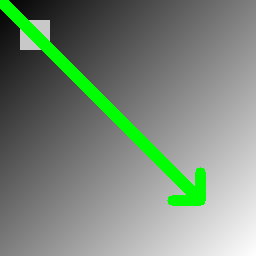

In [36]:
res = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
cv2_imshow(res)